# House Prices — Regression Model V3

V2 model was a disaster with so many noise in the processing of the data and mistakes in code which led to tuning of the wrong model.

After I shared the V2 model, Claude thoroughly studied my model and gave me suggestions to improve and why we need to improve it. This taught me so many concepts and realisation of the true power of AI model, Damn Claude you beauty.

**Suggestions take from Claude:**

| Issue in V2 | Fix in V3 | Why it matters |
|---|---|---|
| `Id` fed to model as a numeric feature | Dropped before preprocessing | `Id` has no predictive meaning; can add noise, especially for trees |
| `MSSubClass` treated as numeric | Cast to string → routed to categorical branch | It's a coded building class, not a magnitude |
| No scaling for Ridge/Lasso | `StandardScaler` added to numeric pipeline | Regularization penalizes coefficient size, which depends on feature scale |
| `LotFrontage` filled with global median | Filled with **neighborhood median** | Frontage varies systematically by neighborhood |
| Skewed numeric predictors left as-is | `log1p` applied to skewed numeric features | Stabilizes variance, helps linear models |
| No outlier check | Removed known `GrLivArea` outliers | A handful of extreme points distort linear model fits |
| RF tuned by default | Best model from CV comparison is tuned (data-driven) | No point tuning a model that didn't win |
| Single model only | XGBoost added; simple blend at the end | Model diversity usually beats any single model on tabular data |




## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

pd.set_option("display.max_columns", 100)
RANDOM_STATE = 42


## 2. Load data

In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

test_ids = test["Id"].copy()  # keep for the submission file

print("train:", train.shape, " test:", test.shape)
train.head()


train: (1460, 81)  test: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 3. EDA 



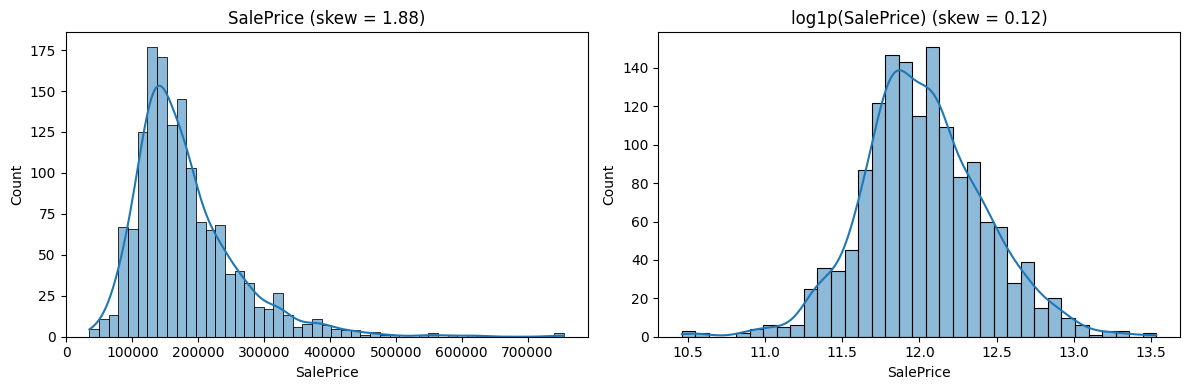

In [4]:
# Q1: Is the target skewed? (affects choice of loss/metric and whether to log-transform)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title(f"SalePrice (skew = {skew(train['SalePrice']):.2f})")

log_price = np.log1p(train["SalePrice"])
sns.histplot(log_price, kde=True, ax=axes[1])
axes[1].set_title(f"log1p(SalePrice) (skew = {skew(log_price):.2f})")
plt.tight_layout()
plt.show()


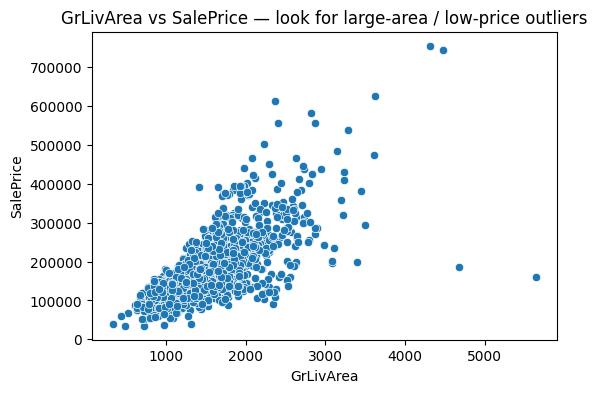

In [ ]:
# Q2: Are there outliers that will distort a linear fit?
# Issue was identfied in V2, a few very large homes sold for surprisingly little.
plt.figure(figsize=(6, 4))
sns.scatterplot(x=train["GrLivArea"], y=train["SalePrice"])
plt.title("GrLivArea vs SalePrice — look for large-area / low-price outliers")
plt.show()


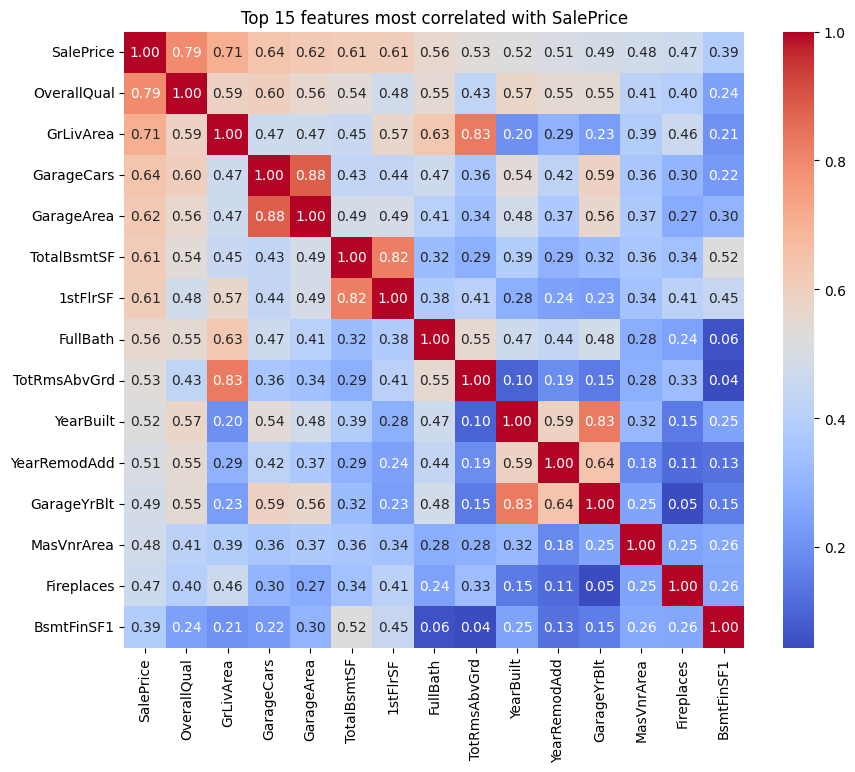

In [6]:
# Q3: Which numeric features actually relate to price, and where's the multicollinearity?
corr = train.corr(numeric_only=True)
top_corr_cols = corr["SalePrice"].abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(10, 8))
sns.heatmap(train[top_corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Top 15 features most correlated with SalePrice")
plt.show()


In [7]:
# Q4: Where are the missing values, and are they "actually missing" or "structurally absent"?
missing = train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_pct = (missing / len(train) * 100).round(1)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})


,missing_count,missing_pct
PoolQC,1453,99.5
MiscFeature,1406,96.3
Alley,1369,93.8
Fence,1179,80.8
MasVnrType,872,59.7
FireplaceQu,690,47.3
LotFrontage,259,17.7
GarageQual,81,5.5
GarageFinish,81,5.5
GarageType,81,5.5


## 4. Remove known outliers

Two houses have `GrLivArea > 4000` but sold for under $300k — well outside the normal price-area
relationship. They're widely known data-entry artifacts in this dataset (per the Ames dataset author's
own notes), not real market signal. Left in, they pull linear model coefficients toward fitting these
two points at the expense of everything else. We only touch `train` — never drop rows from `test`,
since every test row must get a prediction.


In [8]:
outliers = train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)]
print(f"Dropping {len(outliers)} outlier rows")

train = train.drop(outliers.index).reset_index(drop=True)


Dropping 2 outlier rows


## 5. Log-transform the target

In [9]:
# The competition metric is RMSE on log(SalePrice). Log-transforming now means our CV RMSE
# during model comparison is measured on the same scale we'll actually be judged on.
train["SalePrice"] = np.log1p(train["SalePrice"])


## 6. Missing values

Per the data dictionary, for several categorical columns `NaN` doesn't mean "missing" — it means
"this feature doesn't apply to this house" (e.g. no pool → `PoolQC` is NaN). We fill those with the
explicit string `"None"` so the model can learn "no pool" as its own category, rather than losing
that signal to blind imputation.

`LotFrontage` is different: it's a genuinely missing numeric value, but a *global* median ignores that
frontage varies by neighborhood (dense urban blocks vs. large suburban lots). We fill it with the
**neighborhood median** instead — a locally-aware estimate beats a single global number.


In [10]:
fill_none = [
    "PoolQC", "Alley", "Fence", "FireplaceQu",
    "GarageType", "GarageFinish", "GarageQual", "GarageCond",
    "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
    "MasVnrType", "MiscFeature"
]

for col in fill_none:
    train[col] = train[col].fillna("None")
    test[col] = test[col].fillna("None")

# Neighborhood-grouped median for LotFrontage — compute the lookup from TRAIN only,
# then apply it to both train and test (never derive imputation values from test data).
frontage_by_neighborhood = train.groupby("Neighborhood")["LotFrontage"].median()

def fill_lot_frontage(df):
    df = df.copy()
    df["LotFrontage"] = df.apply(
        lambda row: frontage_by_neighborhood.get(row["Neighborhood"], frontage_by_neighborhood.median())
        if pd.isna(row["LotFrontage"]) else row["LotFrontage"],
        axis=1
    )
    return df

train = fill_lot_frontage(train)
test = fill_lot_frontage(test)


## 7. Feature engineering

Same core ideas as V2 (`TotalSF`, `HouseAge`, `RemodelAge`, `TotalBath`), plus a few additions that
tend to help on this dataset: porch square footage combined into one signal, and binary "has X" flags
for amenities where the *presence* matters more than the exact size (a lot of houses have 0 for these,
so the raw square footage is mostly zeros with a long tail — a flag captures the signal more directly).

We also fix the two dtype bugs from V2 here: `Id` is dropped (it's an identifier, not a feature), and
`MSSubClass` is cast to string so it's treated as the categorical code it actually is, not a magnitude.


In [11]:
def feature_engineering(df):
    df = df.copy()

    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["RemodelAge"] = df["YrSold"] - df["YearRemodAdd"]
    df["TotalBath"] = (
        df["FullBath"] + 0.5 * df["HalfBath"]
        + df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"]
    )

    df["TotalPorchSF"] = (
        df["OpenPorchSF"] + df["EnclosedPorch"]
        + df["3SsnPorch"] + df["ScreenPorch"]
    )

    df["HasPool"] = (df["PoolArea"] > 0).astype(int)
    df["HasGarage"] = (df["GarageArea"] > 0).astype(int)
    df["HasFireplace"] = (df["Fireplaces"] > 0).astype(int)
    df["Has2ndFloor"] = (df["2ndFlrSF"] > 0).astype(int)
    df["HasBasement"] = (df["TotalBsmtSF"] > 0).astype(int)

    # MSSubClass is a coded category (20, 30, 60...), not a magnitude — treat it as text
    df["MSSubClass"] = df["MSSubClass"].astype(str)

    return df

train = feature_engineering(train)
test = feature_engineering(test)

# Id is a row identifier, not a predictor — drop it here, before it ever reaches the pipeline
train = train.drop(columns=["Id"])
test_features = test.drop(columns=["Id"])


## 8. Fix skewed numeric predictors


A feature like `LotArea` has a few very large values that dominate a linear model's loss function
disproportionately. We apply `log1p` to any numeric feature with skew above a common threshold (0.75),
computed on train and applied identically to test.


In [12]:
X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns
skewed_feats = X[numeric_cols].apply(lambda col: skew(col.dropna())).sort_values(ascending=False)
skewed_cols = skewed_feats[abs(skewed_feats) > 0.75].index.tolist()

print(f"Log-transforming {len(skewed_cols)} skewed numeric features")

for col in skewed_cols:
    X[col] = np.log1p(X[col].clip(lower=0))
    test_features[col] = np.log1p(test_features[col].clip(lower=0))


Log-transforming 24 skewed numeric features


## 9. Preprocessing pipeline

In [13]:
from sklearn.compose import make_column_selector, ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_features = make_column_selector(dtype_include=["int64", "float64"])
categorical_features = make_column_selector(dtype_include=["object"])

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())          # <-- added: needed for fair Ridge/Lasso regularization
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


## 10. Model comparison

Same CV setup as V2 (5-fold, RMSE on the log target — this matches the competition's actual scoring
metric). XGBoost is added since gradient-boosted trees are typically the strongest single model on
tabular data like this.


In [14]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from xgboost import XGBRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=10),
    "Lasso": Lasso(alpha=0.001, max_iter=10000),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=3,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1
    )
}

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, regressor in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("regressor", regressor)])
    scores = -cross_val_score(pipe, X, y, cv=kf, scoring="neg_root_mean_squared_error", n_jobs=-1)
    results.append({"Model": name, "Mean RMSE": scores.mean(), "Std RMSE": scores.std()})

results_df = pd.DataFrame(results).sort_values("Mean RMSE").reset_index(drop=True)
results_df


,Model,Mean RMSE,Std RMSE
0,Lasso,0.111605,0.007916
1,Ridge,0.112097,0.008058
2,XGBoost,0.117616,0.008253
3,Linear Regression,0.132016,0.012772
4,Random Forest,0.136250,0.006365


## 11. Tune the model  won

This is data-driven rather than assumed: whichever model had the lowest mean CV RMSE above gets
tuned. 

In [15]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Best model from CV comparison: {best_model_name}")


Best model from CV comparison: Lasso


In [16]:
from sklearn.model_selection import RandomizedSearchCV

# One search space per candidate model — only the winner's grid actually gets used
param_grids = {
    "Random Forest": {
        "regressor__n_estimators": [200, 300, 500],
        "regressor__max_depth": [None, 10, 20],
        "regressor__min_samples_split": [2, 5],
        "regressor__min_samples_leaf": [1, 2],
        "regressor__max_features": ["sqrt"]
    },
    "XGBoost": {
        "regressor__n_estimators": [300, 500, 800],
        "regressor__max_depth": [2, 3, 4, 5],
        "regressor__learning_rate": [0.01, 0.03, 0.05, 0.1],
        "regressor__subsample": [0.6, 0.8, 1.0],
        "regressor__colsample_bytree": [0.6, 0.8, 1.0]
    },
    "Ridge": {"regressor__alpha": [0.1, 1, 5, 10, 20, 50]},
    "Lasso": {"regressor__alpha": [0.0001, 0.0005, 0.001, 0.005, 0.01]},
    "Linear Regression": {}   # nothing to tune
}

best_pipe = Pipeline([("preprocessor", preprocessor), ("regressor", models[best_model_name])])
grid = param_grids[best_model_name]

if grid:
    search = RandomizedSearchCV(
        best_pipe, param_distributions=grid, n_iter=15,
        scoring="neg_root_mean_squared_error", cv=kf,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=1
    )
    search.fit(X, y)
    tuned_model = search.best_estimator_
    print("Best params:", search.best_params_)
    print("Best CV RMSE:", -search.best_score_)
else:
    best_pipe.fit(X, y)
    tuned_model = best_pipe


Fitting 5 folds for each of 5 candidates, totalling 25 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 5 is smaller than n_iter=15. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best params: {'regressor__alpha': 0.0005}
Best CV RMSE: 0.1099222856312975


## 12. Blend with a second, diverse model

A tuned single model is good; blending with a model that makes *different kinds* of errors is usually
better. Tree-based and linear models tend to be complementary — trees capture non-linear interactions,
linear/regularized models generalize smoothly on the many near-linear relationships in this dataset.
We fit **Lasso** as the second model (or Ridge, if Lasso happened to be the CV winner already —
swap in whichever wasn't already selected as best), and take a simple weighted average, weighted by
each model's inverse CV RMSE.


In [17]:
second_model_name = "Lasso" if best_model_name != "Lasso" else "Ridge"
second_grid = param_grids[second_model_name]
second_pipe = Pipeline([("preprocessor", preprocessor), ("regressor", models[second_model_name])])

second_search = RandomizedSearchCV(
    second_pipe, param_distributions=second_grid, n_iter=10,
    scoring="neg_root_mean_squared_error", cv=kf,
    random_state=RANDOM_STATE, n_jobs=-1
)
second_search.fit(X, y)
second_tuned_model = second_search.best_estimator_

rmse_best = -search.best_score_ if grid else -cross_val_score(
    tuned_model, X, y, cv=kf, scoring="neg_root_mean_squared_error").mean()
rmse_second = -second_search.best_score_

# Inverse-RMSE weighting: the model with lower error gets more say in the blend
w_best = (1 / rmse_best) / (1 / rmse_best + 1 / rmse_second)
w_second = 1 - w_best

print(f"{best_model_name} CV RMSE: {rmse_best:.4f}  (weight {w_best:.2f})")
print(f"{second_model_name} CV RMSE: {rmse_second:.4f}  (weight {w_second:.2f})")


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Lasso CV RMSE: 0.1099  (weight 0.50)
Ridge CV RMSE: 0.1119  (weight 0.50)


## 13. Fit on full training data and predict on test

In [18]:
tuned_model.fit(X, y)
second_tuned_model.fit(X, y)

pred_log_best = tuned_model.predict(test_features)
pred_log_second = second_tuned_model.predict(test_features)

blended_log = w_best * pred_log_best + w_second * pred_log_second
final_pred = np.expm1(blended_log)

# Safety: prices can't be negative or zero — clip just in case a prediction lands below it
final_pred = np.clip(final_pred, a_min=1, a_max=None)


## 14. Build and sanity-check the submission file

In [19]:
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": final_pred
})

# Sanity checks before uploading — cheap to run, saves a wasted submission
assert len(submission) == len(test), "Row count mismatch with test.csv"
assert submission["SalePrice"].isnull().sum() == 0, "Found NaN predictions"
assert (submission["SalePrice"] > 0).all(), "Found non-positive predicted prices"

submission.to_csv("submission.csv", index=False)
print("submission.csv written:", submission.shape)
submission.head()


submission.csv written: (1459, 2)


,Id,SalePrice
0,1461,119497.505849
1,1462,154911.096895
2,1463,184029.644497
3,1464,199449.807113
4,1465,195510.545136


## Where to go from here

To push the score further after this baseline:
- **LightGBM** as a third blend component — often as strong as XGBoost but trains faster, and its errors are usually correlated with XGBoost's but not identical.
- **Stacking with a meta-learner** instead of a fixed-weight blend: train a simple model (e.g. Ridge) on the out-of-fold predictions of your base models, letting it learn the blend weights instead of hand-setting them.
- **Target/frequency encoding** for high-cardinality categoricals like `Neighborhood`, as an alternative to one-hot — fewer columns, and can capture more signal for linear models.
- **Feature selection** on the one-hot expanded feature set (e.g. `SelectFromModel` on Lasso coefficients) — reduces noise dimensions.
